In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from pathlib import Path
import os
from dotenv import load_dotenv
# Sklearn imports
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
# ścieżka do aktualnego notebooka / katalogu roboczego
project_root = Path.cwd().parent
print(project_root)
# ścieżka do pliku CSV
data_path = project_root / "data" / "raw" / "BankChurners.csv"

# wczytanie danych
df = pd.read_csv(data_path)

df.head()

x:\Programowanie\Projekty\Credit_churn_project


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
#usunięcie ostatnich dwóch kolumn
df = df.iloc[:, :-2]
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [4]:
load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)


In [5]:
df.to_sql("bank_churners", engine, if_exists="replace", index=False)

10127

In [8]:
target_col = 'Attrition_Flag'
print(f"Target Variable: {target_col}")

# Class distribution
class_dist = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print(f"\n Class Distribution:\n{class_dist}")
print(f"\n Class Percentages:\n{class_pct}")

Target Variable: Attrition_Flag

 Class Distribution:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

 Class Percentages:
Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64


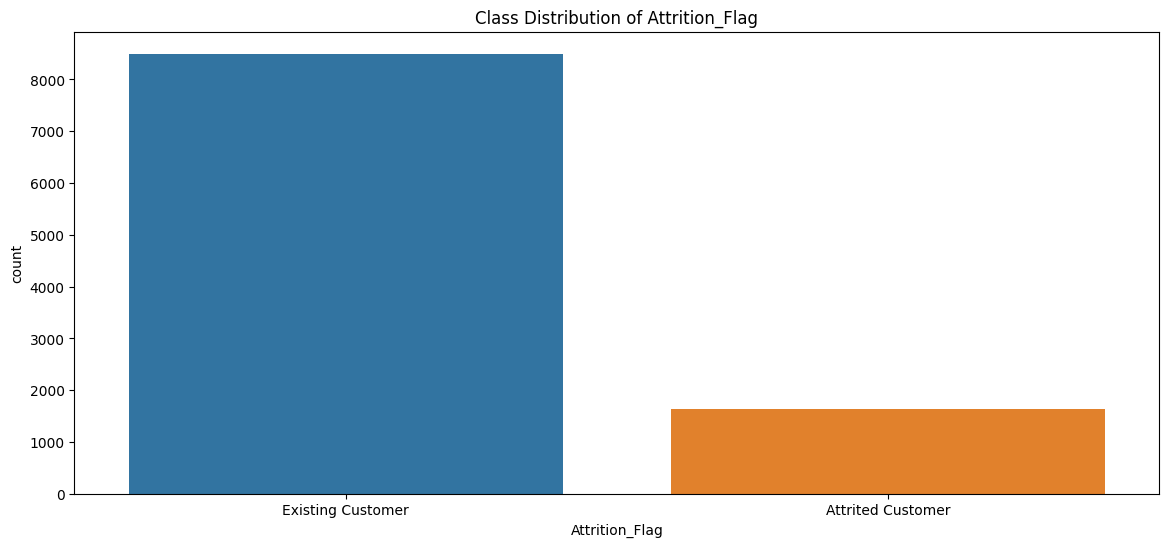

In [14]:
plt.figure(figsize = (14,6))
sns.countplot(data=df, x=target_col, hue=target_col)
plt.title('Class Distribution of Attrition_Flag')
plt.show()

In [ ]:
# FEATURE CATEGORIZATION
#DROP ID column
df = df.drop(columns=['CLIENTNUM'])

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'str']).columns.tolist()

if target_col in categorical_features:
    categorical_features.remove(target_col)

print(f"\n📊 Numerical Features ({len(numerical_features)}):")
for i, feat in enumerate(numerical_features, 1):
    print(f"  {i}. {feat}")

print(f"\n📝 Categorical Features ({len(categorical_features)}):")
for i, feat in enumerate(categorical_features, 1):
    unique_count = df[feat].nunique()
    print(f"  {i}. {feat} ({unique_count} unique values)")


📊 Numerical Features (14):
  1. Customer_Age
  2. Dependent_count
  3. Months_on_book
  4. Total_Relationship_Count
  5. Months_Inactive_12_mon
  6. Contacts_Count_12_mon
  7. Credit_Limit
  8. Total_Revolving_Bal
  9. Avg_Open_To_Buy
  10. Total_Amt_Chng_Q4_Q1
  11. Total_Trans_Amt
  12. Total_Trans_Ct
  13. Total_Ct_Chng_Q4_Q1
  14. Avg_Utilization_Ratio

📝 Categorical Features (5):
  1. Gender (2 unique values)
  2. Education_Level (7 unique values)
  3. Marital_Status (4 unique values)
  4. Income_Category (6 unique values)
  5. Card_Category (4 unique values)


In [22]:
# Detailed statistics
print("\n\nDetailed Statistics:")
stats_df = df[numerical_features].describe().T
stats_df['skewness'] = df[numerical_features].skew()
stats_df['kurtosis'] = df[numerical_features].kurtosis()
print(stats_df.round(2))



Detailed Statistics:
                            count     mean      std     min      25%      50%  \
Customer_Age              10127.0    46.33     8.02    26.0    41.00    46.00   
Dependent_count           10127.0     2.35     1.30     0.0     1.00     2.00   
Months_on_book            10127.0    35.93     7.99    13.0    31.00    36.00   
Total_Relationship_Count  10127.0     3.81     1.55     1.0     3.00     4.00   
Months_Inactive_12_mon    10127.0     2.34     1.01     0.0     2.00     2.00   
Contacts_Count_12_mon     10127.0     2.46     1.11     0.0     2.00     2.00   
Credit_Limit              10127.0  8631.95  9088.78  1438.3  2555.00  4549.00   
Total_Revolving_Bal       10127.0  1162.81   814.99     0.0   359.00  1276.00   
Avg_Open_To_Buy           10127.0  7469.14  9090.69     3.0  1324.50  3474.00   
Total_Amt_Chng_Q4_Q1      10127.0     0.76     0.22     0.0     0.63     0.74   
Total_Trans_Amt           10127.0  4404.09  3397.13   510.0  2155.50  3899.00   
Total

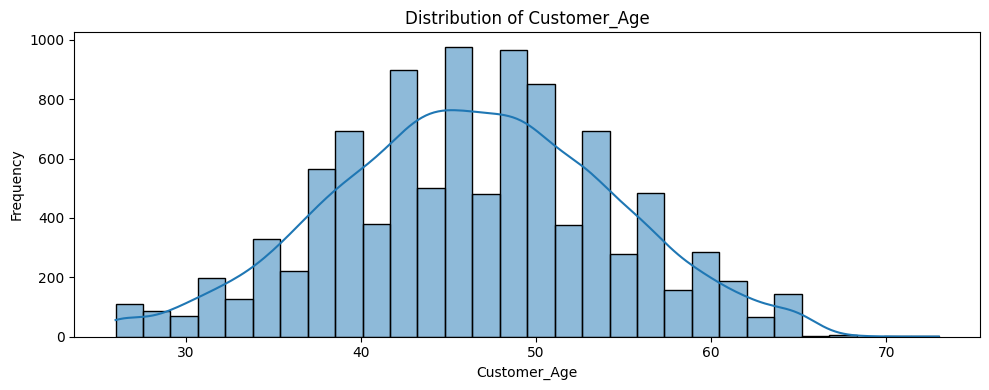

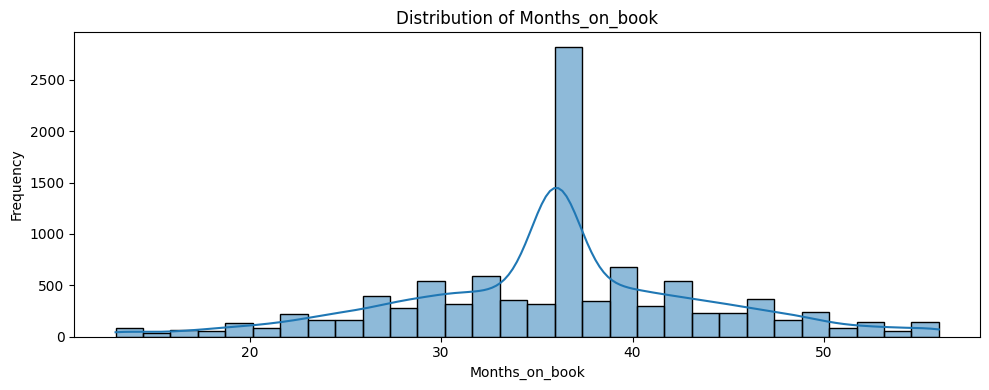

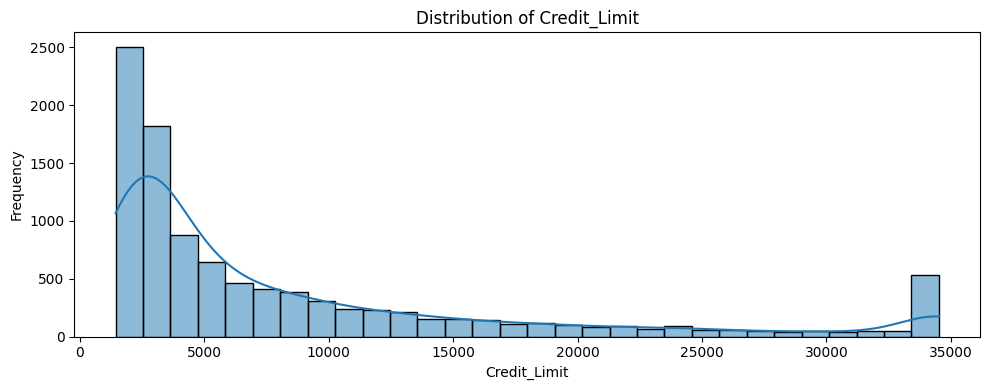

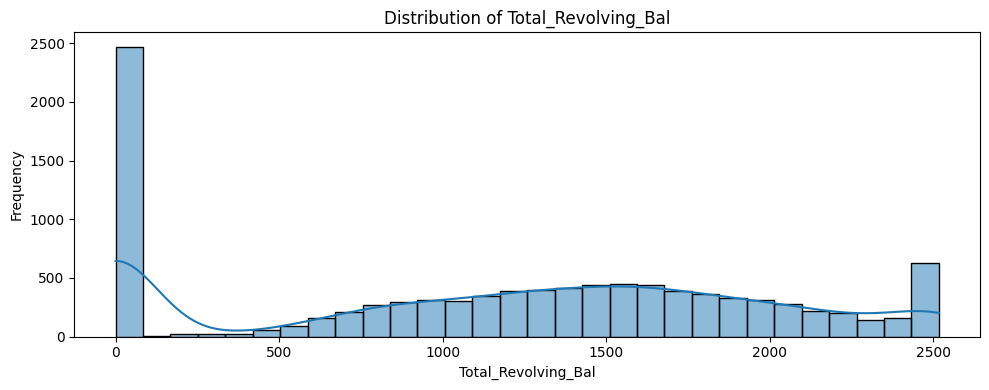

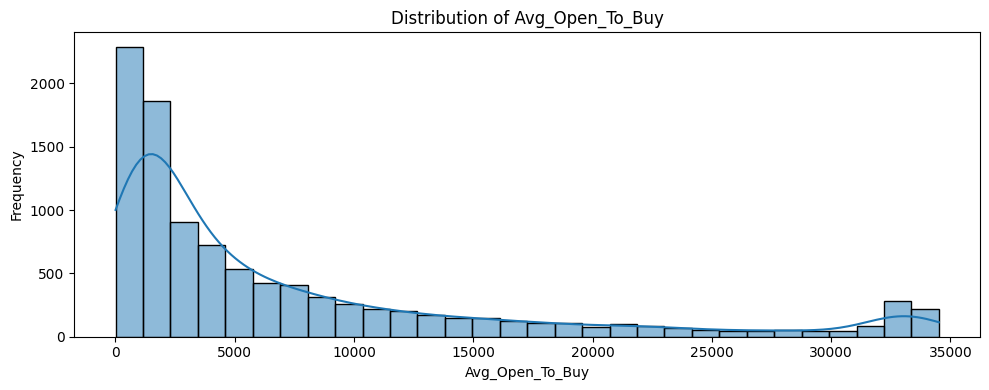

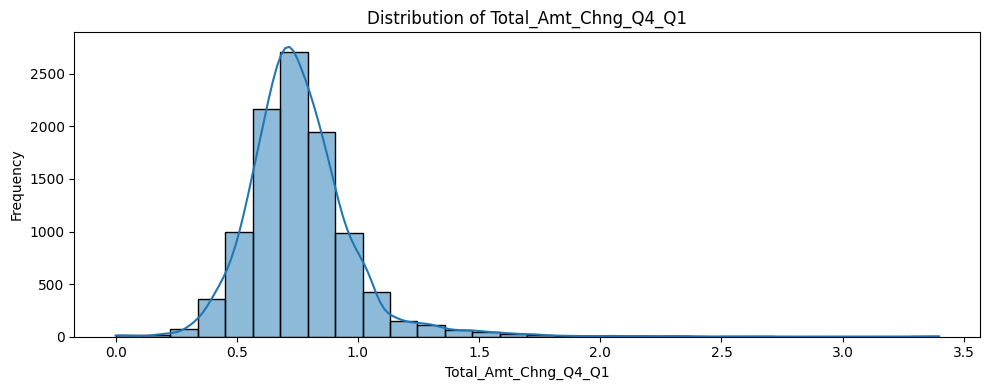

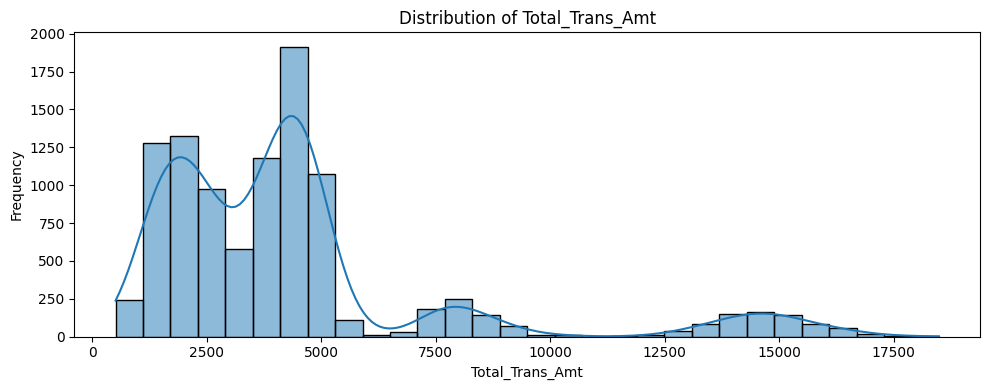

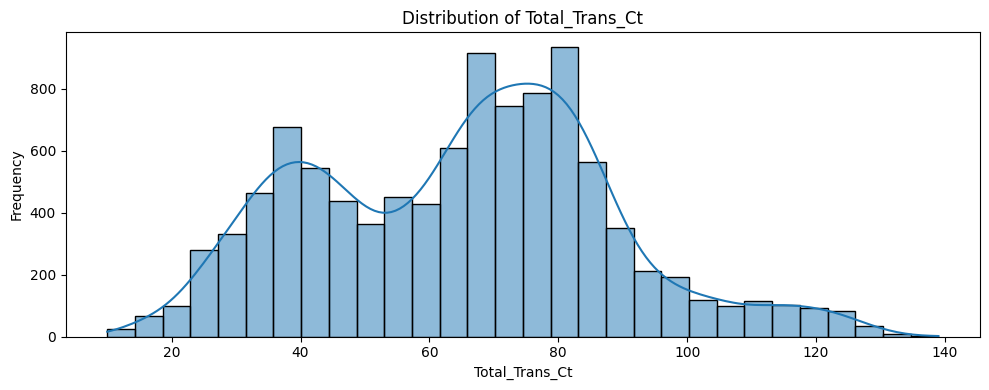

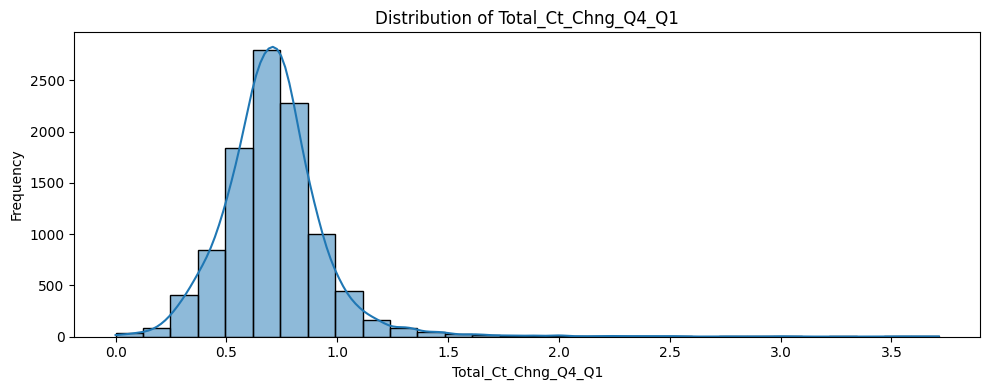

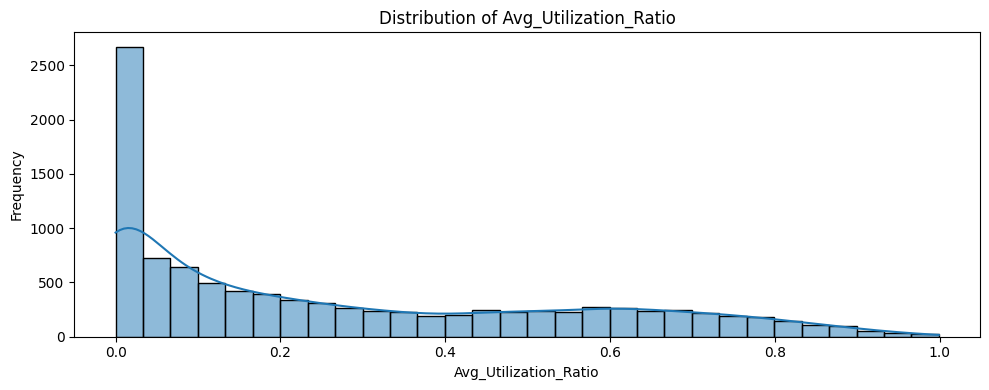

In [35]:
#Distribution plots for numerical features
num_features_to_plot = df[['Customer_Age', 'Months_on_book', 'Credit_Limit', 
                       'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']].columns.to_list()


for feature in num_features_to_plot:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

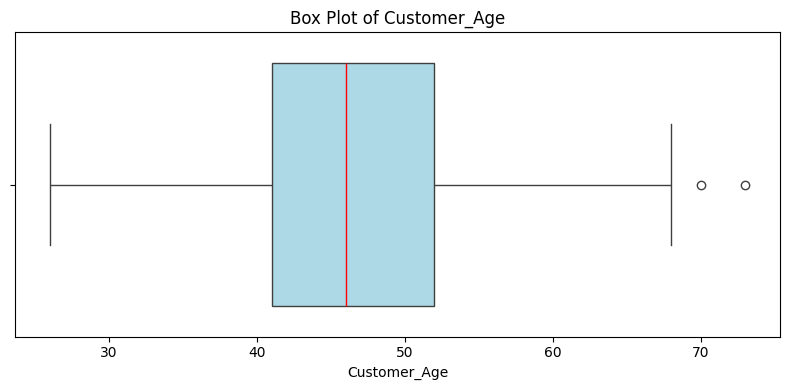

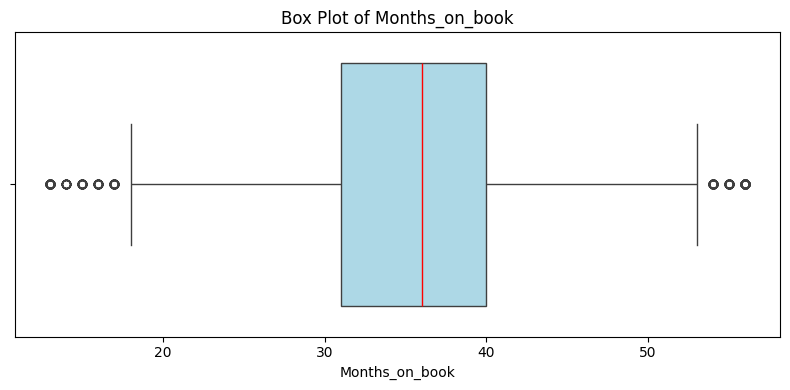

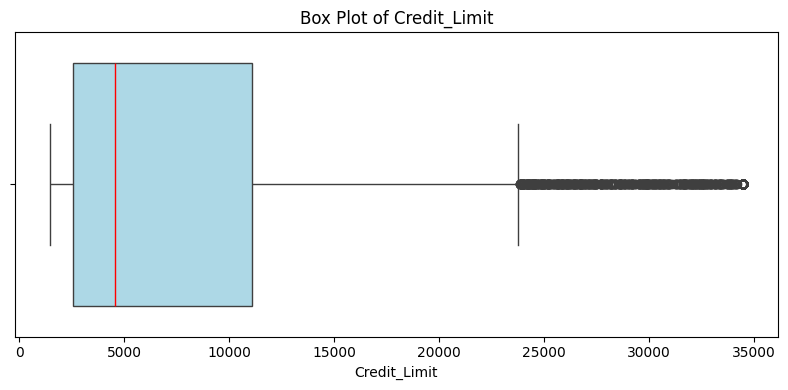

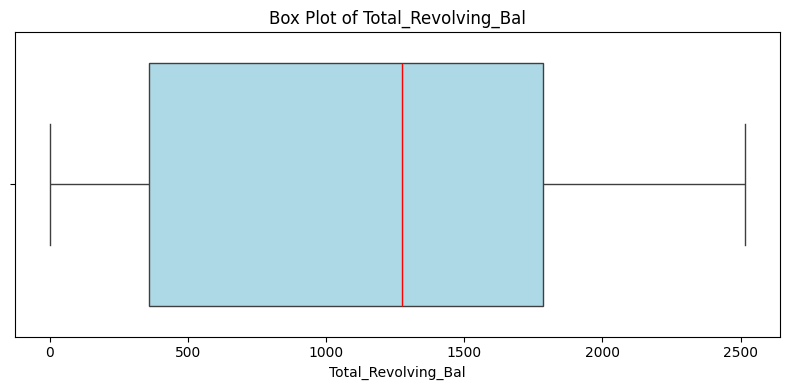

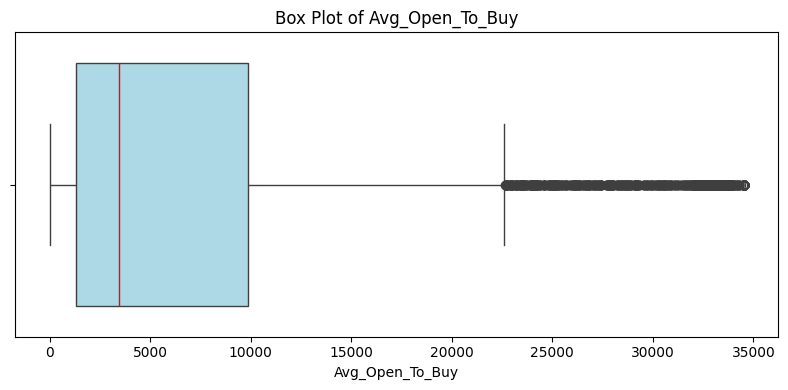

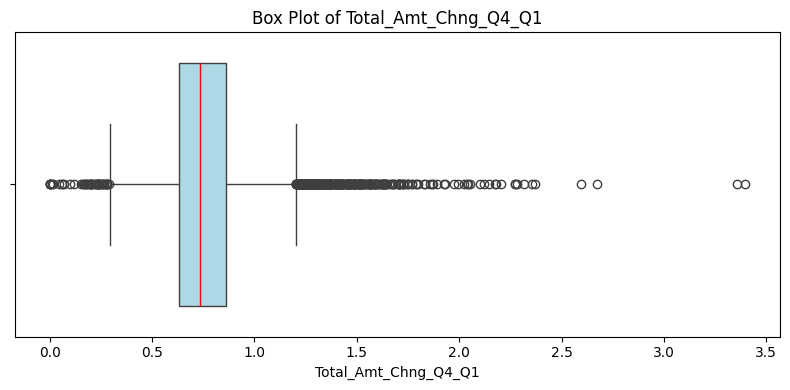

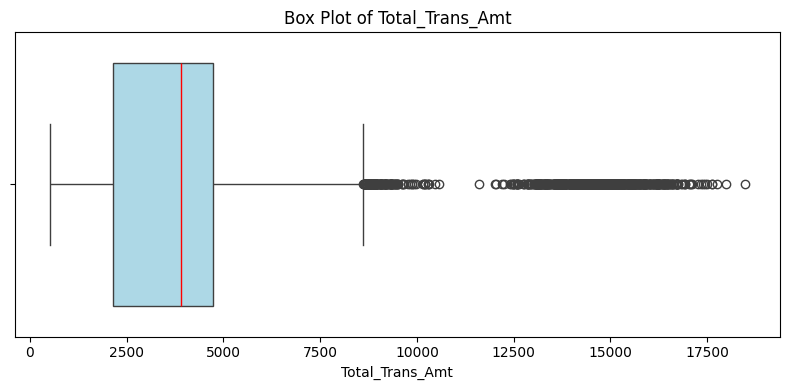

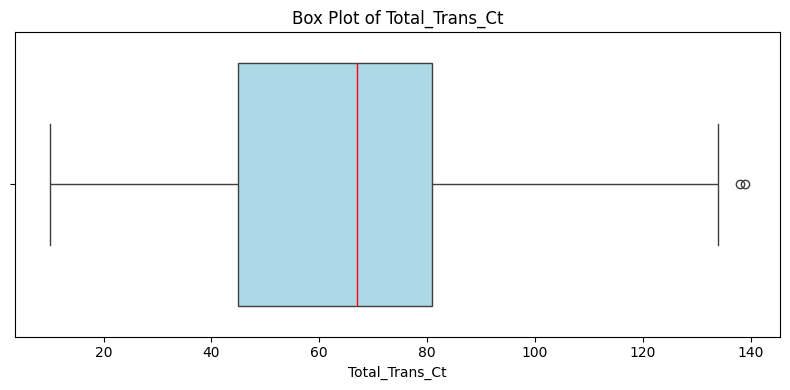

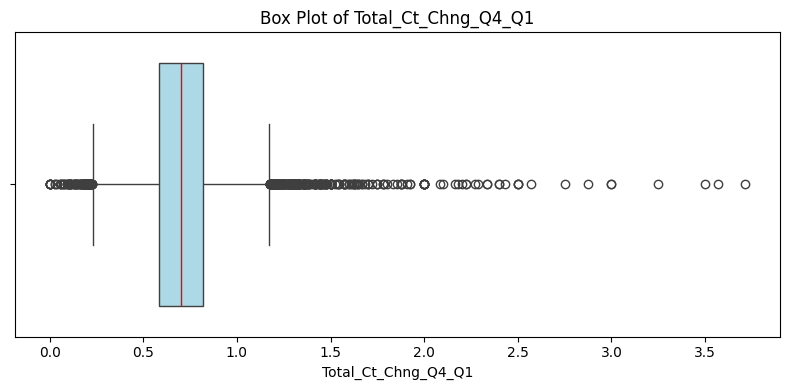

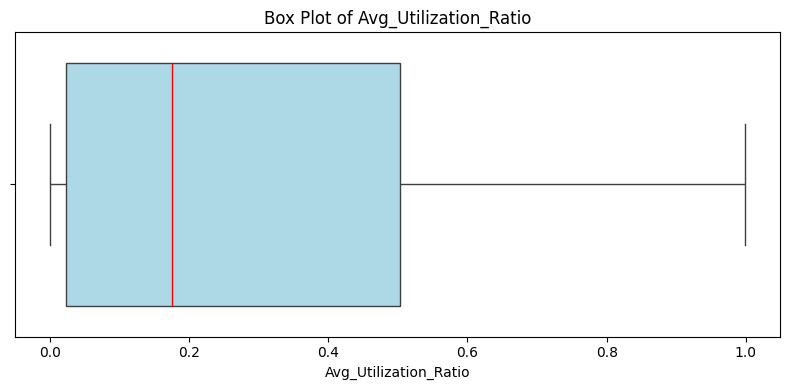

In [36]:
#BOX PLOTS FOR NUMERICAL FEATURES and potential outliers
for feature in num_features_to_plot:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature], medianprops={"color": "red"}, boxprops={"facecolor": "lightblue"})
    plt.title(f'Box Plot of {feature}')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

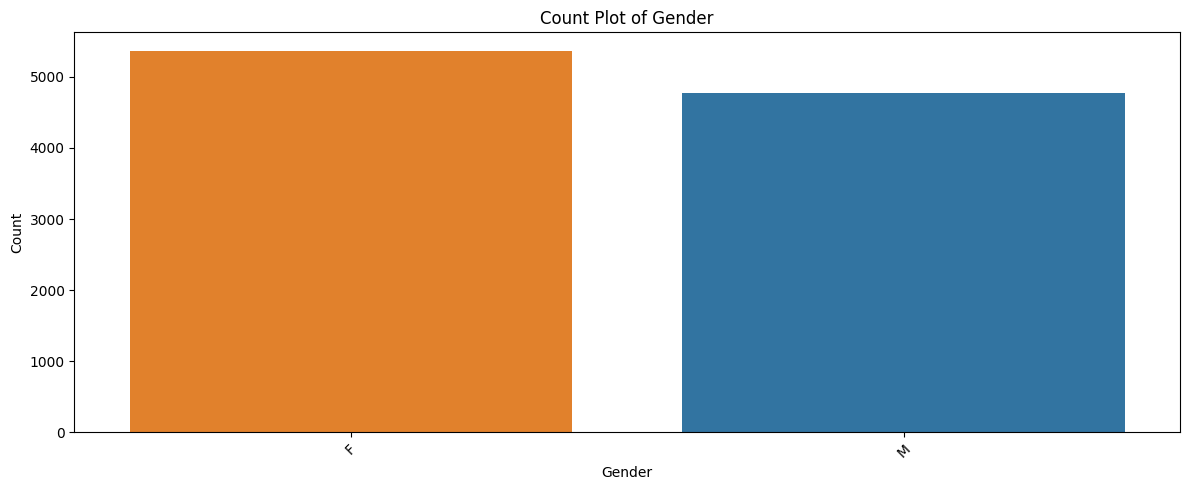

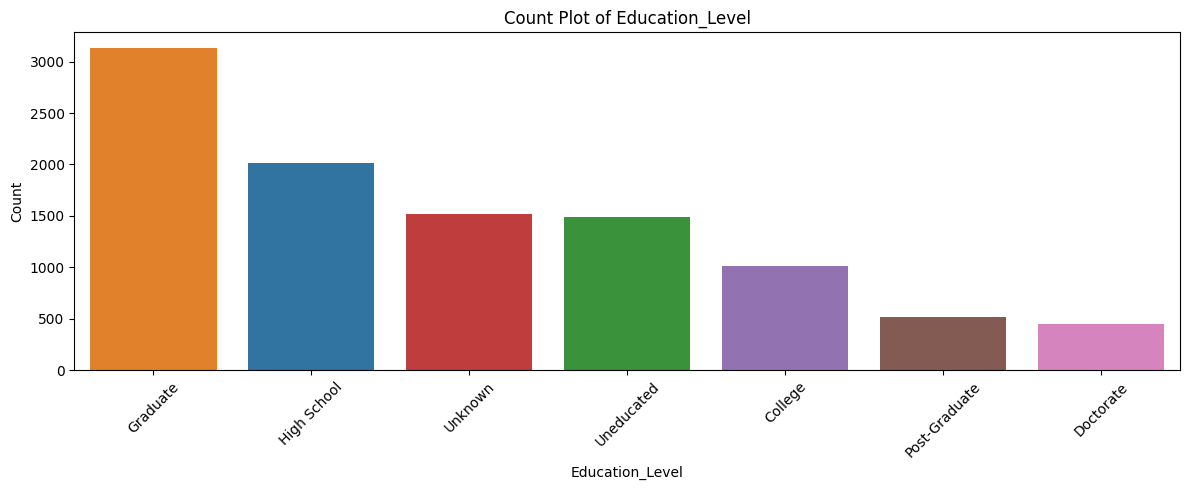

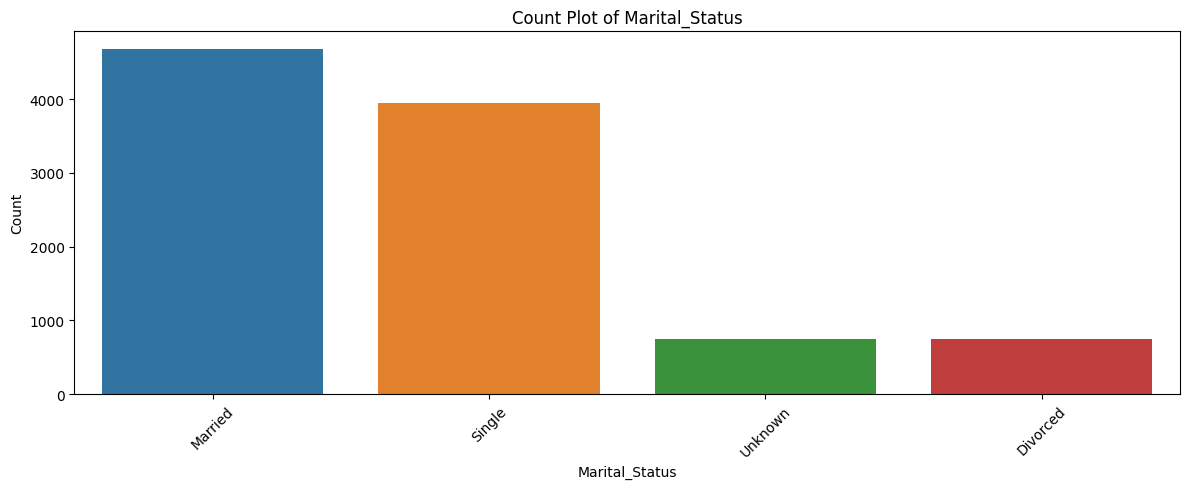

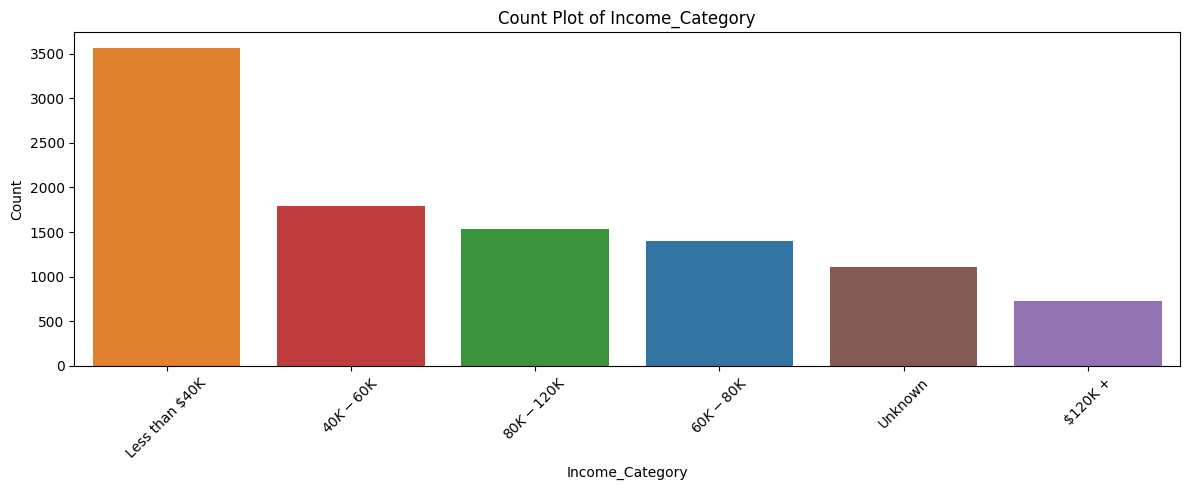

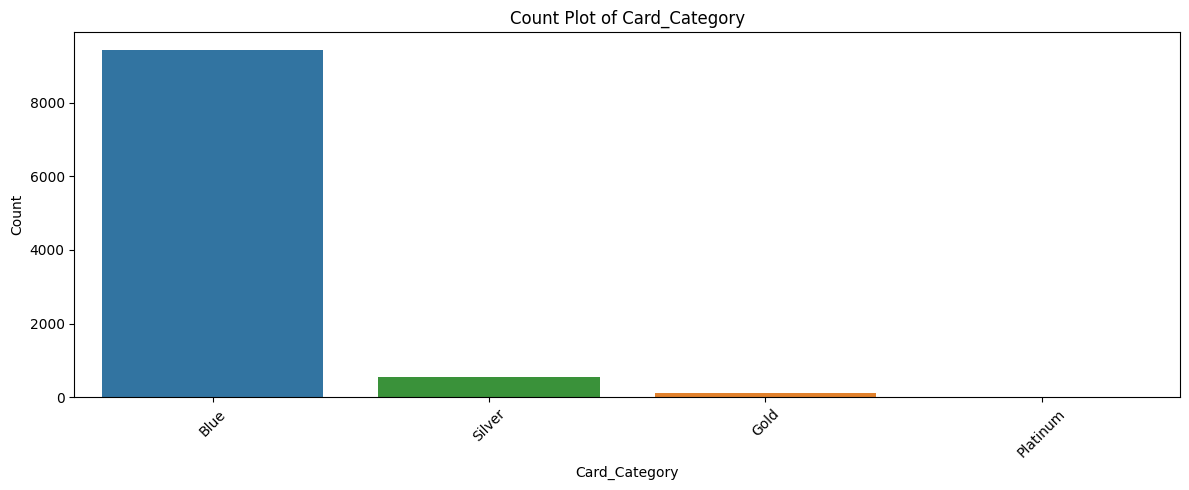

In [37]:
#Categorical features visualization
for feature in categorical_features:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index, hue=feature)
    plt.title(f'Count Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
#Unknown values - we treat them as valid and informative data. 
# Usually in banking industry, "Unknown" can indicate a lack of customer engagement or willingness to 
# share information, which may correlate with churn risk.

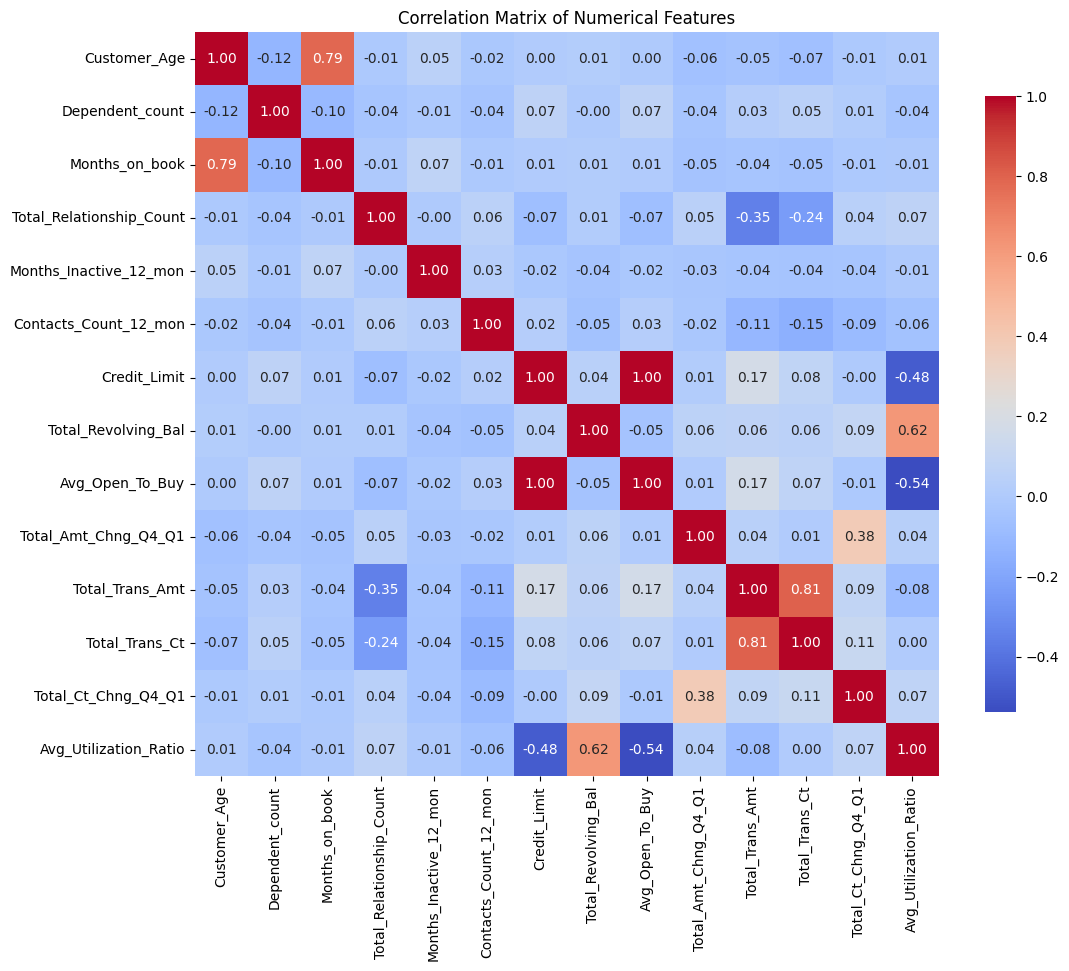

In [38]:
#Correlation analysis
# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features')
plt.show()